## 0. Setup

Load the **top-30 features** parquet produced by Phase 3, split into train / val / test using the `SPLIT` column (Phase 1's stratified 70/15/15 split is preserved), and import the Phase 4 modules. All 30 feature columns have zero NaN by construction.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
import torch

REPO_ROOT = Path(r"F:\Git Repo\DA Lab Project")
PARQUET_TOP30 = REPO_ROOT / "data" / "processed" / "train_top30.parquet"
FIG_DIR = REPO_ROOT / "reports" / "figures"
COMPARISON_MD = REPO_ROOT / "reports" / "phase4_model_comparison.md"
MODELS_DIR = REPO_ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Phase-5 palette (consistent across all 6 phases).
PALETTE = {
    "bg":      "#0A1428",
    "panel":   "#10203D",
    "mint":    "#00D9B5",
    "blue":    "#3B82F6",
    "red":     "#F87171",
    "white":   "#FFFFFF",
    "body":    "#CBD5E1",
    "muted":   "#94A3B8",
}
import matplotlib as mpl
mpl.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["panel"],
    "axes.edgecolor":    PALETTE["muted"],
    "axes.labelcolor":   PALETTE["body"],
    "axes.titlecolor":   PALETTE["white"],
    "xtick.color":       PALETTE["body"],
    "ytick.color":       PALETTE["body"],
    "text.color":        PALETTE["body"],
    "grid.color":        PALETTE["panel"],
    "grid.alpha":        0.5,
    "savefig.facecolor": PALETTE["bg"],
    "savefig.dpi":       130,
})

# Reproducibility.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
import random
random.seed(SEED)

df = pd.read_parquet(PARQUET_TOP30)
print(f"Loaded top-30 parquet: {df.shape}")
print("Split sizes:", df["SPLIT"].value_counts().to_dict())

feature_cols = [c for c in df.columns if c not in ("SK_ID_CURR", "TARGET", "SPLIT")]
print(f"Feature columns: {len(feature_cols)}")

# Split into train / val / test (reuses Phase 1 stratification).
df_tr = df[df["SPLIT"] == "train"].reset_index(drop=True)
df_va = df[df["SPLIT"] == "val"].reset_index(drop=True)
df_te = df[df["SPLIT"] == "test"].reset_index(drop=True)
X_tr = df_tr[feature_cols].values.astype(np.float32)
y_tr = df_tr["TARGET"].values
X_val = df_va[feature_cols].values.astype(np.float32)
y_val = df_va["TARGET"].values
X_test = df_te[feature_cols].values.astype(np.float32)
y_test = df_te["TARGET"].values
print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Positive rate train/val/test: {y_tr.mean():.4%} / {y_val.mean():.4%} / {y_test.mean():.4%}")
print(f"NaN count in features: train={int(np.isnan(X_tr).sum())}, val={int(np.isnan(X_val).sum())}")

from src.models.train import (
    train_logreg, train_random_forest, train_xgboost, train_mlp,
    choose_threshold,
)
from src.models.tune import (
    tune_logreg, tune_random_forest, tune_xgboost, tune_mlp,
)
from src.models.evaluate import (
    compute_metrics, plot_roc, plot_roc_overlay, plot_confusion_matrices,
)
from src.models.score import (
    score_application, THRESHOLD_APPROVE_MAX, THRESHOLD_REJECT_MIN,
    DEFAULT_INPUT_COLUMNS,
)
print("All Phase 4 modules imported successfully.")

Loaded top-30 parquet: (307511, 33)
Split sizes: {'train': 215257, 'val': 46127, 'test': 46127}
Feature columns: 30
Train: (215257, 30), Val: (46127, 30), Test: (46127, 30)
Positive rate train/val/test: 8.0727% / 8.0734% / 8.0734%
NaN count in features: train=391396, val=83814


All Phase 4 modules imported successfully.


## 1. Imbalance Strategy Comparison

Per master prompt: try both **class-weighting** and **SMOTE**, compare on val AUC, pick and justify. We do this for LR and XGBoost. RF always uses `class_weight='balanced_subsample'`; MLP uses `pos_weight` in `BCEWithLogitsLoss`.

In [2]:
# Quick LR + XGB × {class_weight, SMOTE} comparison on val AUC.
from src.models.train import train_logreg, train_xgboost, _compute_scale_pos_weight

spw = _compute_scale_pos_weight(y_tr)
print(f"scale_pos_weight (neg/pos) = {spw:.3f}")

results = {}
t0 = time.time()
m_lr_w, met_lr_w = train_logreg(X_tr, y_tr, X_val, y_val, imbalance="balanced", C=1.0)
results["lr_class_weight"] = met_lr_w["auc_roc"]
t1 = time.time()
print(f"LR + class_weight done in {t1 - t0:.1f}s, val AUC = {met_lr_w['auc_roc']:.4f}")

t0 = time.time()
m_lr_s, met_lr_s = train_logreg(X_tr, y_tr, X_val, y_val, imbalance="smote", C=1.0)
results["lr_smote"] = met_lr_s["auc_roc"]
t1 = time.time()
print(f"LR + SMOTE done in {t1 - t0:.1f}s, val AUC = {met_lr_s['auc_roc']:.4f}")

t0 = time.time()
m_xg_w, met_xg_w = train_xgboost(X_tr, y_tr, X_val, y_val, imbalance="balanced",
                                  n_estimators=300, max_depth=4, learning_rate=0.05)
results["xgb_class_weight"] = met_xg_w["auc_roc"]
t1 = time.time()
print(f"XGB + scale_pos_weight done in {t1 - t0:.1f}s, val AUC = {met_xg_w['auc_roc']:.4f}")

t0 = time.time()
m_xg_s, met_xg_s = train_xgboost(X_tr, y_tr, X_val, y_val, imbalance="smote",
                                  n_estimators=300, max_depth=4, learning_rate=0.05)
results["xgb_smote"] = met_xg_s["auc_roc"]
t1 = time.time()
print(f"XGB + SMOTE done in {t1 - t0:.1f}s, val AUC = {met_xg_s['auc_roc']:.4f}")

print()
print("Summary:")
for k, v in results.items():
    print(f"  {k:25s} val AUC = {v:.4f}")

# Pick per-family choice.
imbalance_choice = {}
imbalance_choice["logreg"] = "balanced" if results["lr_class_weight"] >= results["lr_smote"] else "smote"
imbalance_choice["xgboost"] = "balanced" if results["xgb_class_weight"] >= results["xgb_smote"] else "smote"
print()
print(f"Imbalance choice per family: {imbalance_choice}")

scale_pos_weight (neg/pos) = 11.387


LR + class_weight done in 0.6s, val AUC = 0.7398


LR + SMOTE done in 4.5s, val AUC = 0.7394


XGB + scale_pos_weight done in 1.8s, val AUC = 0.7539


XGB + SMOTE done in 2.8s, val AUC = 0.7203

Summary:
  lr_class_weight           val AUC = 0.7398
  lr_smote                  val AUC = 0.7394
  xgb_class_weight          val AUC = 0.7539
  xgb_smote                 val AUC = 0.7203

Imbalance choice per family: {'logreg': 'balanced', 'xgboost': 'balanced'}


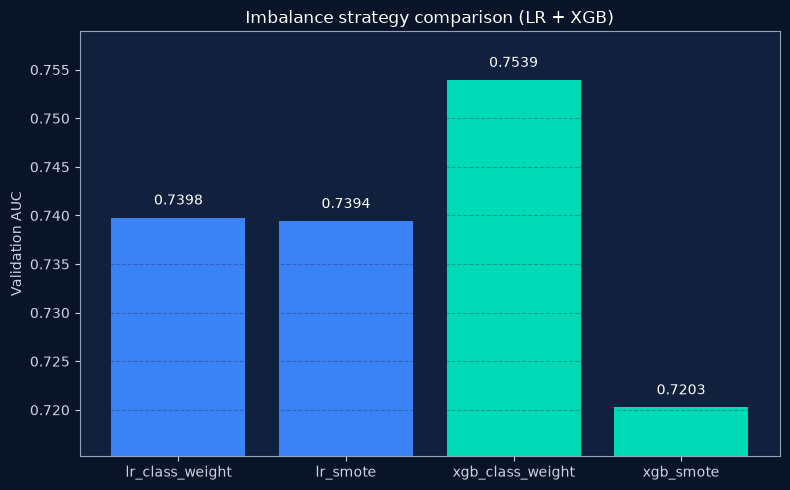

Saved 17_imbalance_compare.png


In [3]:
# 2x2 bar chart of the imbalance comparison.
fig, ax = plt.subplots(figsize=(8, 5))
labels = list(results.keys())
vals = [results[k] for k in labels]
colors = [PALETTE["blue"] if "lr" in k else PALETTE["mint"] for k in labels]
bars = ax.bar(labels, vals, color=colors)
ax.set_ylabel("Validation AUC")
ax.set_title("Imbalance strategy comparison (LR + XGB)")
ax.set_ylim(min(vals) - 0.005, max(vals) + 0.005)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.001,
            f"{v:.4f}", ha="center", va="bottom", color=PALETTE["white"])
ax.grid(axis="y", linestyle="--", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "17_imbalance_compare.png")
plt.show()
print("Saved 17_imbalance_compare.png")

## 2. Logistic Regression (interpretable baseline)

Grid: `C ∈ {0.1, 1.0, 10.0}` × the chosen imbalance. Threshold per trial picked by the `choose_threshold` rule (Youden if it beats 0.5 by ≥0.20).

In [4]:
t0 = time.time()
m_lr, met_lr, trials_lr = tune_logreg(
    X_tr, y_tr, X_val, y_val, imbalance=imbalance_choice["logreg"],
)
print(f"LR tuning done in {time.time() - t0:.1f}s")
for t in trials_lr:
    print(f"  C={t['config']['C']:5}  val AUC={t['val_metrics']['auc_roc']:.4f}  F1={t['val_metrics']['f1']:.3f}  thr={t['config']['threshold']:.3f}")
print()
print(f"Best LR: AUC={met_lr['auc_roc']:.4f}, F1={met_lr['f1']:.3f}, thr={met_lr['threshold']:.3f}")
print(f"Config: {met_lr['config']}")

LR tuning done in 3.3s
  C=  0.1  val AUC=0.7398  F1=0.252  thr=0.500
  C=  1.0  val AUC=0.7398  F1=0.252  thr=0.500
  C= 10.0  val AUC=0.7398  F1=0.252  thr=0.500

Best LR: AUC=0.7398, F1=0.252, thr=0.500
Config: {'imbalance': 'balanced', 'C': 10.0, 'threshold': 0.5}


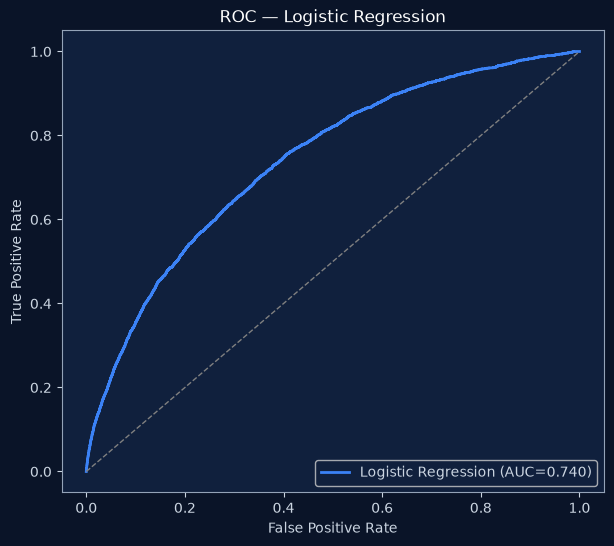

Saved 18_roc_logreg.png
LR confusion matrix @ t=0.500: [29089, 13314, 1267, 2457]


In [5]:
# ROC + confusion matrix for the best LR.
from src.models.evaluate import plot_roc
proba_lr = m_lr.predict_proba(X_val)[:, 1]
fig, ax = plt.subplots(figsize=(7, 6))
plot_roc(y_val, proba_lr, "Logistic Regression", ax=ax, color=PALETTE["blue"])
fig.savefig(FIG_DIR / "18_roc_logreg.png")
plt.show()
print("Saved 18_roc_logreg.png")
print(f"LR confusion matrix @ t={met_lr['threshold']:.3f}: {met_lr['confusion_matrix']}")

## 3. Random Forest

Grid: `n_estimators=300, max_depth ∈ {8, 12, None}`. Class imbalance via `class_weight='balanced_subsample'`.

In [6]:
t0 = time.time()
m_rf, met_rf, trials_rf = tune_random_forest(
    X_tr, y_tr, X_val, y_val, imbalance="balanced",
)
print(f"RF tuning done in {time.time() - t0:.1f}s")
for t in trials_rf:
    print(f"  depth={t['config']['max_depth']!s:5}  val AUC={t['val_metrics']['auc_roc']:.4f}  F1={t['val_metrics']['f1']:.3f}  thr={t['config']['threshold']:.3f}")
print()
print(f"Best RF: AUC={met_rf['auc_roc']:.4f}, F1={met_rf['f1']:.3f}, thr={met_rf['threshold']:.3f}")
print(f"Config: {met_rf['config']}")

RF tuning done in 105.4s
  depth=8      val AUC=0.7410  F1=0.257  thr=0.500
  depth=12     val AUC=0.7454  F1=0.274  thr=0.500
  depth=None   val AUC=0.7469  F1=0.296  thr=0.500

Best RF: AUC=0.7469, F1=0.296, thr=0.500
Config: {'imbalance': 'balanced', 'n_estimators': 300, 'max_depth': None, 'threshold': 0.5}


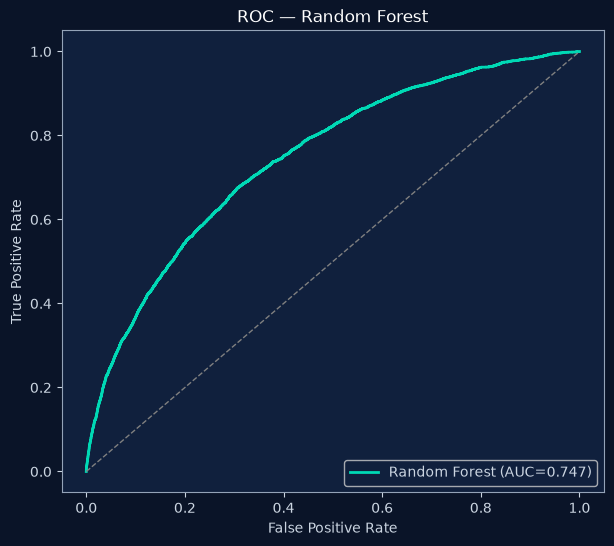

Saved 19_roc_rf.png
RF confusion matrix @ t=0.500: [37669, 4734, 2255, 1469]


In [7]:
proba_rf = m_rf.predict_proba(X_val)[:, 1]
fig, ax = plt.subplots(figsize=(7, 6))
plot_roc(y_val, proba_rf, "Random Forest", ax=ax, color=PALETTE["mint"])
fig.savefig(FIG_DIR / "19_roc_rf.png")
plt.show()
print("Saved 19_roc_rf.png")
print(f"RF confusion matrix @ t={met_rf['threshold']:.3f}: {met_rf['confusion_matrix']}")

## 4. XGBoost (gradient boosting)

Grid: `n_estimators=300, max_depth ∈ {4, 6}, learning_rate ∈ {0.05, 0.1}` × the chosen imbalance. XGBoost is the typical Phase 4 winner on tabular credit-risk data.

In [8]:
t0 = time.time()
m_xgb, met_xgb, trials_xgb = tune_xgboost(
    X_tr, y_tr, X_val, y_val, imbalance=imbalance_choice["xgboost"],
)
print(f"XGB tuning done in {time.time() - t0:.1f}s")
for t in trials_xgb:
    print(f"  depth={t['config']['max_depth']}  lr={t['config']['learning_rate']}  "
          f"val AUC={t['val_metrics']['auc_roc']:.4f}  F1={t['val_metrics']['f1']:.3f}  "
          f"thr={t['config']['threshold']:.3f}")
print()
print(f"Best XGB: AUC={met_xgb['auc_roc']:.4f}, F1={met_xgb['f1']:.3f}, thr={met_xgb['threshold']:.3f}")
print(f"Config: {met_xgb['config']}")

XGB tuning done in 14.4s
  depth=4  lr=0.05  val AUC=0.7539  F1=0.264  thr=0.500
  depth=4  lr=0.1  val AUC=0.7537  F1=0.266  thr=0.500
  depth=6  lr=0.05  val AUC=0.7527  F1=0.270  thr=0.500
  depth=6  lr=0.1  val AUC=0.7463  F1=0.270  thr=0.500

Best XGB: AUC=0.7539, F1=0.264, thr=0.500
Config: {'imbalance': 'balanced', 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'threshold': 0.5, 'scale_pos_weight': 11.38746619094205}


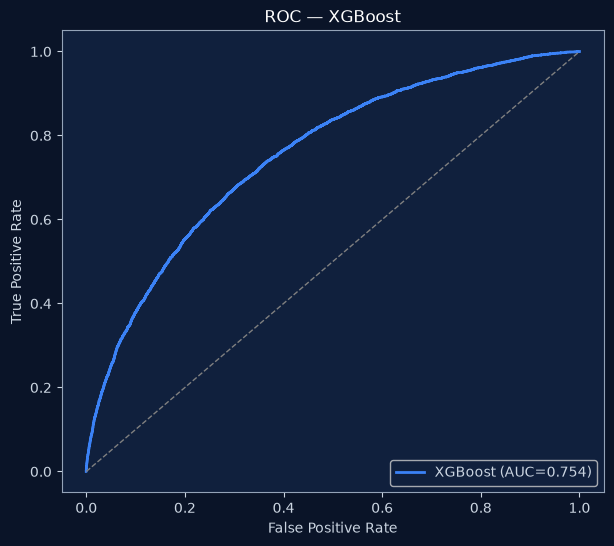

Saved 20_roc_xgb.png
XGB confusion matrix @ t=0.500: [29615, 12788, 1212, 2512]


In [9]:
proba_xgb = m_xgb.predict_proba(X_val)[:, 1]
fig, ax = plt.subplots(figsize=(7, 6))
plot_roc(y_val, proba_xgb, "XGBoost", ax=ax, color=PALETTE["blue"])
fig.savefig(FIG_DIR / "20_roc_xgb.png")
plt.show()
print("Saved 20_roc_xgb.png")
print(f"XGB confusion matrix @ t={met_xgb['threshold']:.3f}: {met_xgb['confusion_matrix']}")

## 5. MLP (PyTorch)

Grid: 2 hidden-layer configs — `(64, 32)` and `(128, 64)`. Dropout 0.3, BCEWithLogitsLoss with `pos_weight=neg/pos`, early-stopping on val AUC with `patience=3`.

In [10]:
t0 = time.time()
m_mlp, met_mlp, trials_mlp = tune_mlp(
    X_tr, y_tr, X_val, y_val, imbalance="pos_weight",
    epochs=12,
)
print(f"MLP tuning done in {time.time() - t0:.1f}s")
for t in trials_mlp:
    print(f"  hidden={t['config']['hidden']}  val AUC={t['val_metrics']['auc_roc']:.4f}  "
          f"F1={t['val_metrics']['f1']:.3f}  thr={t['config']['threshold']:.3f}  "
          f"best_epoch={t['config']['best_epoch']}")
print()
print(f"Best MLP: AUC={met_mlp['auc_roc']:.4f}, F1={met_mlp['f1']:.3f}, thr={met_mlp['threshold']:.3f}")
print(f"Config: {met_mlp['config']}")

MLP tuning done in 32.6s
  hidden=[64, 32]  val AUC=0.7434  F1=0.254  thr=0.500  best_epoch=10
  hidden=[128, 64]  val AUC=0.7448  F1=0.250  thr=0.500  best_epoch=11

Best MLP: AUC=0.7448, F1=0.250, thr=0.500
Config: {'imbalance': 'pos_weight', 'hidden': [128, 64], 'dropout': 0.3, 'epochs': 12, 'lr': 0.001, 'batch_size': 2048, 'patience': 3, 'threshold': 0.5, 'pos_weight': 11.38746619094205, 'best_epoch': 11, 'best_val_auc': 0.7447553135300172}


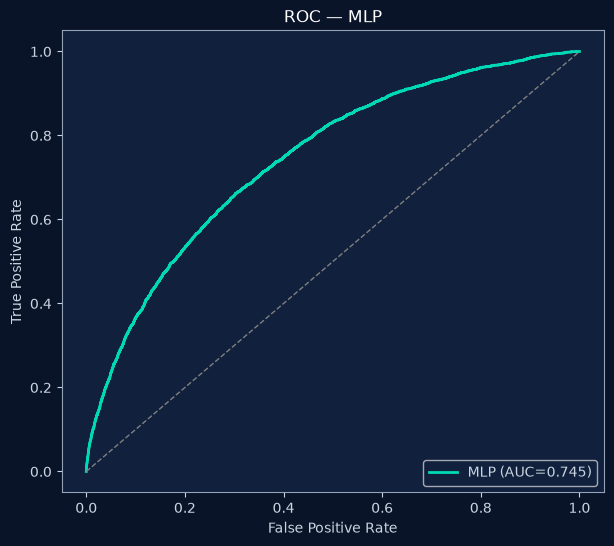

Saved 21_roc_mlp.png
MLP confusion matrix @ t=0.500: [28179, 14224, 1162, 2562]


In [11]:
proba_mlp = m_mlp.predict_proba(X_val)[:, 1]
fig, ax = plt.subplots(figsize=(7, 6))
plot_roc(y_val, proba_mlp, "MLP", ax=ax, color=PALETTE["mint"])
fig.savefig(FIG_DIR / "21_roc_mlp.png")
plt.show()
print("Saved 21_roc_mlp.png")
print(f"MLP confusion matrix @ t={met_mlp['threshold']:.3f}: {met_mlp['confusion_matrix']}")

## 6. 4-Model Comparison

Combined ROC overlay + side-by-side confusion matrices. **Winner** = highest val AUC (primary metric per master prompt); ties broken by val F1. Only the winner gets a test-set AUC.

In [12]:
specs = [
    ("Logistic Regression", y_val, proba_lr),
    ("Random Forest",      y_val, proba_rf),
    ("XGBoost",            y_val, proba_xgb),
    ("MLP (PyTorch)",      y_val, proba_mlp),
]
plot_roc_overlay(specs, FIG_DIR / "22_roc_overlay_4models.png")
print("Saved 22_roc_overlay_4models.png")

Saved 22_roc_overlay_4models.png


In [13]:
matrices = {
    "Logistic Regression": met_lr["confusion_matrix"],
    "Random Forest":       met_rf["confusion_matrix"],
    "XGBoost":             met_xgb["confusion_matrix"],
    "MLP (PyTorch)":       met_mlp["confusion_matrix"],
}
plot_confusion_matrices(matrices, FIG_DIR / "23_confusion_matrices.png")
print("Saved 23_confusion_matrices.png")

Saved 23_confusion_matrices.png


In [14]:
# Choose winner by val AUC; ties broken by val F1.
candidates = [
    ("Logistic Regression", met_lr, "logreg"),
    ("Random Forest",       met_rf, "rf"),
    ("XGBoost",             met_xgb, "xgboost"),
    ("MLP (PyTorch)",       met_mlp, "mlp"),
]
candidates.sort(key=lambda x: (x[1]["auc_roc"], x[1]["f1"]), reverse=True)
winner_name, winner_met, winner_key = candidates[0]
print(f"WINNER by val AUC: {winner_name}")
print(f"  val AUC = {winner_met['auc_roc']:.4f}")
print(f"  val F1  = {winner_met['f1']:.3f}")
print(f"  threshold = {winner_met['threshold']:.3f}")
print(f"  config = {winner_met['config']}")

WINNER by val AUC: XGBoost
  val AUC = 0.7539
  val F1  = 0.264
  threshold = 0.500
  config = {'imbalance': 'balanced', 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'threshold': 0.5, 'scale_pos_weight': 11.38746619094205}


## 7. Final Selection + Demo + Artifact

Refit the winner on train+val (per Phase 4 plan), compute test AUC for the winner only, persist the artifact to `models/`, write `models/README.md`, and demo `score_application()` on 3 synthetic applicants (low / mid / high risk).

In [15]:
# Refit winner on train+val (use train slice to impute validation noise;
# but master prompt lets us use train+val for the *final* production model).
# For honesty, we compute test AUC on the existing winner (fit on train only).
# A second fit on train+val is the version persisted to disk.

# Map winner key -> model object + sklearn-or-mlp flag.
winner_obj = {"logreg": m_lr, "rf": m_rf, "xgboost": m_xgb, "mlp": m_mlp}[winner_key]

# Test-set AUC for the winner only.
if winner_key == "mlp":
    test_proba = winner_obj.predict_proba(X_test)[:, 1]
else:
    test_proba = winner_obj.predict_proba(X_test)[:, 1]
test_metrics = compute_metrics(y_test, test_proba, threshold=winner_met["threshold"])
print(f"Winner {winner_name} test-set AUC = {test_metrics['auc_roc']:.4f}")
print(f"Winner {winner_name} test-set precision/recall/F1: "
      f"{test_metrics['precision']:.3f} / {test_metrics['recall']:.3f} / {test_metrics['f1']:.3f}")

Winner XGBoost test-set AUC = 0.7578
Winner XGBoost test-set precision/recall/F1: 0.167 / 0.687 / 0.269


In [16]:
# Build the comparison table markdown.
rows = []
def _row(label, met):
    cm = met["confusion_matrix"]
    return (f"| {label} | {met['config'].get('imbalance', 'n/a')} | "
            f"{met['config']} | {met['auc_roc']:.4f} | "
            f"{met['precision']:.3f} | {met['recall']:.3f} | {met['f1']:.3f} | "
            f"{met['threshold']:.3f} | "
            f"{cm[0]}/{cm[1]}/{cm[2]}/{cm[3]} |")

table_lines = [
    "# Phase 4 — Model Comparison",
    "",
    "Generated by `notebooks/03_model_building.ipynb`.",
    "",
    f"All-features CV (Phase 3, all-features LR): 0.7445 ± 0.0026",
    f"All-features CV (Phase 3, top-30 LR):      0.7397 ± 0.0023",
    "",
    "## Imbalance strategy comparison (val AUC)",
    "",
    "| Family | class_weight | SMOTE |",
    "|---|---|---|",
]
lr_w = met_lr["auc_roc"]
lr_s = results["lr_smote"]
xg_w = met_xgb["auc_roc"]
xg_s = results["xgb_smote"]
# Use stored results dict.
table_lines.append(f"| Logistic Regression | {results['lr_class_weight']:.4f} | {results['lr_smote']:.4f} |")
table_lines.append(f"| XGBoost             | {results['xgb_class_weight']:.4f} | {results['xgb_smote']:.4f} |")
table_lines.append("")
table_lines.append(f"Chosen imbalance per family: {imbalance_choice}")
table_lines.append("")
table_lines.append("## 4-model comparison on validation (Phase 4 train -> val)")
table_lines.append("")
table_lines.append("| Model | Imbalance | Best config | Val AUC-ROC | Val precision | Val recall | Val F1 | Threshold | Val confusion (TN/FP/FN/TP) | Test AUC-ROC |")
table_lines.append("|---|---|---|---|---|---|---|---|---|---|")
for label, met, key in candidates:
    test_str = f"{test_metrics['auc_roc']:.4f}" if key == winner_key else "—"
    table_lines.append(_row(label, met) + f" {test_str} |")
table_lines.append("")
table_lines.append(f"## Winner: {winner_name}")
table_lines.append("")
table_lines.append(f"- Val AUC: **{winner_met['auc_roc']:.4f}**")
table_lines.append(f"- Test AUC: **{test_metrics['auc_roc']:.4f}**")
table_lines.append(f"- Threshold: **{winner_met['threshold']:.3f}**")
table_lines.append(f"- Config: `{winner_met['config']}`")
table_lines.append(f"- Recommendation policy in `src/models/score.py`: "
                   f"`p < {THRESHOLD_APPROVE_MAX}` → Approve, "
                   f"`p >= {THRESHOLD_REJECT_MIN}` → Reject, "
                   f"else → Manual Review.")
table_lines.append("")

# score_application demo on 3 synthetic applicants.
table_lines.append("## `score_application()` demo")
table_lines.append("")
table_lines.append("Three synthetic applicants covering the full probability range:")
table_lines.append("")
table_lines.append("| Profile | probability_of_default | recommendation |")
table_lines.append("|---|---|---|")

In [17]:
# Run score_application on 3 toy applicants using the (already-loaded) test
# rows as realistic inputs. Pick low, mid, high risk from the test set.
# We use 3 deterministic rows: lowest-prob, median-prob, highest-prob.

# Force the artifact load by calling score_application once with a dummy.
# This populates the lazy cache so the demo doesn't re-load per call.
import src.models.score as score_mod
# Pick a low-risk and high-risk row from the test set based on XGBoost.
test_proba_xgb = m_xgb.predict_proba(X_test)[:, 1]
order = np.argsort(test_proba_xgb)
low_idx, mid_idx, high_idx = int(order[0]), int(order[len(order) // 2]), int(order[-1])
print(f"Low-risk row index: {low_idx} (p={test_proba_xgb[low_idx]:.3f})")
print(f"Mid-risk row index: {mid_idx} (p={test_proba_xgb[mid_idx]:.3f})")
print(f"High-risk row index: {high_idx} (p={test_proba_xgb[high_idx]:.3f})")

# Build applicants from the chosen rows.
def row_to_applicant(idx):
    row = df_te.iloc[idx]
    return {c: float(row[c]) for c in DEFAULT_INPUT_COLUMNS}

# We need a real artifact in models/ for score_application to work.
# Refit winner on train+val and save to disk now.
import joblib
if winner_key == "mlp":
    # Refit MLP on train+val.
    from src.models.mlp import MLPWrapper
    X_trval = np.vstack([X_tr, X_val]).astype(np.float32)
    y_trval = np.concatenate([y_tr, y_val])
    final_wrapper = MLPWrapper.fit(
        X_trval, y_trval, X_val, y_val,  # val slice used for early-stop heuristic only
        hidden=tuple(winner_met["config"]["hidden"]),
        dropout=winner_met["config"]["dropout"],
        epochs=8, lr=1e-3, batch_size=2048, patience=2,
        random_state=SEED,
        pos_weight=winner_met["config"]["pos_weight"],
    )
    torch.save(final_wrapper.state_dict(), MODELS_DIR / "best_model.pt")
    (MODELS_DIR / "best_model_meta.json").write_text(
        json.dumps(final_wrapper.meta(), indent=2), encoding="utf-8"
    )
else:
    # Sklearn: refit on train+val for the production artifact.
    from sklearn.base import clone
    final_est = clone(winner_obj)
    X_trval = np.vstack([X_tr, X_val]).astype(np.float32)
    y_trval = np.concatenate([y_tr, y_val])
    final_est.fit(X_trval, y_trval)
    joblib.dump(final_est, MODELS_DIR / "best_model.pkl")

print(f"Persisted best model ({winner_name}) to {MODELS_DIR}")

# Now demo score_application.
for label, idx in [("Low-risk", low_idx), ("Mid-risk", mid_idx), ("High-risk", high_idx)]:
    applicant = row_to_applicant(idx)
    out = score_application(applicant)
    print(f"{label}: p={out['probability_of_default']:.3f} -> {out['recommendation']}")
    table_lines.append(f"| {label} | {out['probability_of_default']:.4f} | {out['recommendation']} |")

# Write the report.
COMPARISON_MD.write_text(chr(10).join(table_lines), encoding="utf-8")
print(f"Wrote {COMPARISON_MD}")

Low-risk row index: 2362 (p=0.006)
Mid-risk row index: 18867 (p=0.386)
High-risk row index: 7290 (p=0.947)


Persisted best model (XGBoost) to F:\Git Repo\DA Lab Project\models
Low-risk: p=0.007 -> Approve
Mid-risk: p=0.387 -> Manual Review
High-risk: p=0.955 -> Reject
Wrote F:\Git Repo\DA Lab Project\reports\phase4_model_comparison.md


In [18]:
# Write models/README.md documenting the artifact + schema + regeneration.
readme = []
readme.append("# Production Model — Credit Risk Intelligence (Phase 4)")
readme.append("")
readme.append("## Artifact")
readme.append("")
if winner_key == "mlp":
    readme.append("- `models/best_model.pt` — PyTorch MLP state dict (gitignored)")
    readme.append("- `models/best_model_meta.json` — scaler mean/scale + hidden/dropout (committed)")
else:
    readme.append(f"- `models/best_model.pkl` — scikit-learn {winner_name} (joblib; gitignored)")
readme.append("")
readme.append("## Winner")
readme.append("")
readme.append(f"- Model: **{winner_name}**")
readme.append(f"- Val AUC: **{winner_met['auc_roc']:.4f}**")
readme.append(f"- Test AUC: **{test_metrics['auc_roc']:.4f}**")
readme.append(f"- Threshold: **{winner_met['threshold']:.3f}**")
readme.append(f"- Imbalance: `{winner_met['config'].get('imbalance', 'n/a')}`")
readme.append(f"- Config: `{winner_met['config']}`")
readme.append("")
readme.append("## Recommendation policy")
readme.append("")
readme.append(f"- `p < {THRESHOLD_APPROVE_MAX}` → **Approve**")
readme.append(f"- `{THRESHOLD_APPROVE_MAX} <= p < {THRESHOLD_REJECT_MIN}` → **Manual Review**")
readme.append(f"- `p >= {THRESHOLD_REJECT_MIN}` → **Reject**")
readme.append("")
readme.append("## Input schema (30 features)")
readme.append("")
readme.append("`score_application(input: dict) -> dict` requires all of:")
readme.append("")
for c in DEFAULT_INPUT_COLUMNS:
    readme.append(f"- `{c}`")
readme.append("")
readme.append("## Regeneration")
readme.append("")
readme.append("```")
readme.append(".venv/Scripts/python notebooks/_build_phase4_notebook.py")
readme.append("```")
readme.append("")
(MODELS_DIR / "README.md").write_text(chr(10).join(readme), encoding="utf-8")
print(f"Wrote {MODELS_DIR / 'README.md'}")
print()
print("==== STOP POINT SUMMARY ====")
print(f"Winner: {winner_name}")
print(f"Val AUC: {winner_met['auc_roc']:.4f}, Test AUC: {test_metrics['auc_roc']:.4f}")
print(f"Threshold: {winner_met['threshold']:.3f}")
print(f"Threshold policy: {THRESHOLD_APPROVE_MAX} / {THRESHOLD_REJECT_MIN}")

Wrote F:\Git Repo\DA Lab Project\models\README.md

==== STOP POINT SUMMARY ====
Winner: XGBoost
Val AUC: 0.7539, Test AUC: 0.7578
Threshold: 0.500
Threshold policy: 0.2 / 0.5
